## 2. Features

### 2-1. Setup

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

tx_df = pd.read_csv("../data/processed/transactions.csv")
logs_df = pd.read_csv("../data/processed/token_transfers.csv")
pd.set_option("display.max_colwidth", 14)

print(f"Transactions: {len(tx_df):,}")
print(f"Token transfers: {len(logs_df):,}")

Transactions: 265,653
Token transfers: 354,440


### 2.2 Pre-Wallet Features from Transactions

In [10]:
tx_df["day"] = pd.to_datetime(tx_df["ts"], unit="s").dt.date

sender_feats = tx_df.groupby("from").agg(
    tx_count=("tx_hash", "count"),
    total_value_eth_sent=("value_eth", "sum"),
    avg_gas=("gas", "mean"),
    contract_call_count=("is_contract_call", "sum"),
    active_days=("day", "nunique"),
    unique_recipients=("to", "nunique"),
    first_ts=("ts", "min"),
    last_ts=("ts", "max"),
).reset_index().rename(columns={"from": "wallet"})

sender_feats["contract_call_ratio"] = sender_feats["contract_call_count"] / sender_feats["tx_count"]
sender_feats["lifespan_hours"] = (sender_feats["last_ts"] - sender_feats["first_ts"]) / 3600
sender_feats["tx_frequency"] = sender_feats["tx_count"] / sender_feats["active_days"]

print(f"Wallets that sent at least one tx: {len(sender_feats):,}")
sender_feats.head()

Wallets that sent at least one tx: 89,622


,wallet,tx_count,total_value_eth_sent,avg_gas,contract_call_count,active_days,unique_recipients,first_ts,last_ts,contract_call_ratio,lifespan_hours,tx_frequency
0,0x00000000...,3,5.889720e-10,1.102725e+06,3,1,1,1778173835,1778179811,1.0,1.660000,3.0
1,0x00000000...,35,8.104086e-09,3.894047e+05,35,1,1,1778172203,1778183291,1.0,3.080000,35.0
2,0x00000000...,4,5.769790e-10,7.919355e+05,4,1,1,1778173223,1778183303,1.0,2.800000,4.0
3,0x00000000...,3,8.699016e-04,1.000003e+06,3,1,1,1778172251,1778179283,1.0,1.953333,3.0
4,0x00000000...,9,2.500000e-01,6.535761e+05,9,1,3,1778172947,1778183315,1.0,2.880000,9.0


### 2.3 Per-Wallet Features from Transactions (Receiver)

In [11]:
receiver_feats = tx_df.groupby("to").agg(
    total_value_eth_received=("value_eth", "sum"),
    received_tx_count=("tx_hash", "count"),
    unique_senders=("from", "nunique"),
).reset_index().rename(columns={"to": "wallet"})

print(f"Wallets that received at least one tx: {len(receiver_feats):,}")
receiver_feats.head()

Wallets that received at least one tx: 52,579


,wallet,total_value_eth_received,received_tx_count,unique_senders
0,0x00000000...,0.000049,7,3
1,0x00000000...,0.000000,1,1
2,0x00000000...,0.000004,1,1
3,0x00000000...,0.000000,3,2
4,0x00000000...,0.000000,1,1


### 2.4 Per-Wallet Features from ERC-20 Logs (Sender)

In [5]:
token_sent = logs_df.groupby("from").agg(
    tokens_sent_count=("tx_hash", "count"),
    unique_tokens_sent=("token", "nunique"),
    unique_token_recipients=("to", "nunique"),
).reset_index().rename(columns={"from": "wallet"})

print(f"Wallets that sent token transfers: {len(token_sent):,}")

Wallets that sent token transfers: 75,794


### 2.5 Per_Wallet Features from ERC-20 Logs (Receiver)

In [ ]:
token_recv = logs_df.groupby("to").agg(
    tokens_received_count=("tx_hash", "count"),
    unique_tokens_received=("token", "nunique"),
    unique_token_senders=("from", "nunique"),
).reset_index().rename(columns={"to": "wallet"})

print(f"Wallets that received token transfers: {len(token_recv):,}")

Wallets that received token transfers: 91,229


### 2.6 Merging into Single Feature

In [12]:
features = (
    sender_feats
    .merge(receiver_feats, on="wallet", how="outer")
    .merge(token_sent, on="wallet", how="outer")
    .merge(token_recv, on="wallet", how="outer")
)

# wallets that only received but never sent will have NaN in tx_count etc — fill with 0
fill_cols = [c for c in features.columns if c != "wallet"]
features[fill_cols] = features[fill_cols].fillna(0)

# derived features
features["send_receive_ratio"] = (
    features["total_value_eth_sent"] / (features["total_value_eth_received"] + 1e-9)
)
features["token_send_receive_ratio"] = (
    features["tokens_sent_count"] / (features["tokens_received_count"] + 1e-9)
)
features["total_token_transfers"] = features["tokens_sent_count"] + features["tokens_received_count"]

print(f"Total unique wallets in window: {len(features):,}")
features.head()

Total unique wallets in window: 175,708


,wallet,tx_count,total_value_eth_sent,avg_gas,contract_call_count,active_days,unique_recipients,first_ts,last_ts,contract_call_ratio,...,unique_senders,tokens_sent_count,unique_tokens_sent,unique_token_recipients,tokens_received_count,unique_tokens_received,unique_token_senders,send_receive_ratio,token_send_receive_ratio,total_token_transfers
0,0x00000000...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,7683.0,935.0,1991.0,4373.0,672.0,931.0,0.0,1.756917,12056.0
1,0x00000000...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.000000,1.0
2,0x00000000...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.000000,1.0
3,0x00000000...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.000000,1.0
4,0x00000000...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


### 2.7 Filter to Wallets to Cluster

In [8]:
# threshold: at least 5 events of any kind (txs sent + txs received + token transfers)
features["total_activity"] = (
    features["tx_count"]
    + features["received_tx_count"]
    + features["total_token_transfers"]
)

active = features[features["total_activity"] >= 5].copy().reset_index(drop=True)
print(f"Wallets with >= 5 events: {len(active):,} (filtered from {len(features):,})")
print(f"  dropped {len(features) - len(active):,} low-activity wallets")

Wallets with >= 5 events: 31,527 (filtered from 175,708)
  dropped 144,181 low-activity wallets


### 2.8. Feature Columns for Clustering

In [ ]:
FEATURE_COLS = [
    "tx_count",
    "total_value_eth_sent",
    "total_value_eth_received",
    "avg_gas",
    "unique_recipients",
    "unique_senders",
    "contract_call_ratio",
    "tx_frequency",
    "tokens_sent_count",
    "tokens_received_count",
    "unique_tokens_sent",
    "unique_tokens_received",
]

active[["wallet"] + FEATURE_COLS].to_csv("../data/processed/wallet_features.csv", index=False)
print(f"Saved wallet_features.csv with {len(active):,} wallets and {len(FEATURE_COLS)} features")
active[FEATURE_COLS].describe()

Saved wallet_features.csv with 31,527 wallets and 14 features


,tx_count,total_value_eth_sent,total_value_eth_received,avg_gas,active_days,unique_recipients,unique_senders,contract_call_ratio,tx_frequency,tokens_sent_count,tokens_received_count,unique_tokens_sent,unique_tokens_received,send_receive_ratio
count,31527.000000,31527.000000,31527.000000,3.152700e+04,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000,3.152700e+04
mean,5.862340,8.941831,7.324524,1.640353e+05,0.699274,2.467726,3.490373,0.585212,5.862340,9.342564,8.538745,1.812827,1.578488,1.459998e+09
std,34.646919,276.890357,242.911947,3.954771e+05,0.458581,14.196998,134.293061,0.460359,34.646919,146.127824,126.856427,7.954472,7.224224,8.168441e+10
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00
50%,2.000000,0.000000,0.000000,6.500000e+04,1.000000,1.000000,0.000000,0.900000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000e+00
75%,4.000000,0.019734,0.000367,1.990408e+05,1.000000,2.000000,1.000000,1.000000,4.000000,4.000000,4.000000,2.000000,2.000000,1.000000e+00
max,2335.000000,27740.000000,26669.787611,1.467882e+07,1.000000,671.000000,19892.000000,1.000000,2335.000000,19949.000000,17401.000000,935.000000,672.000000,1.000000e+13


### 2.9 Standardize

We've log transformed heavy tail (counts/totals) features then standardized the rest.

In [15]:
HEAVY_TAILED = [
    "tx_count", "total_value_eth_sent", "total_value_eth_received", "avg_gas",
    "active_days", "unique_recipients", "unique_senders", "tx_frequency",
    "tokens_sent_count", "tokens_received_count",
    "unique_tokens_sent", "unique_tokens_received",
]
RATIOS = ["contract_call_ratio", "send_receive_ratio"]

X = active[FEATURE_COLS].copy()
for col in HEAVY_TAILED:
    X[col] = np.log1p(X[col])
# clip extreme send_receive_ratio (could be huge from divide-by-near-zero)
X["send_receive_ratio"] = X["send_receive_ratio"].clip(upper=X["send_receive_ratio"].quantile(0.99))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
X_scaled_df.insert(0, "wallet", active["wallet"].values)
X_scaled_df.to_csv("../data/processed/wallet_features_scaled.csv", index=False)

print(f"Saved wallet_features_scaled.csv")
print("\nScaled feature stats (should be ~mean 0, std 1):")
X_scaled_df[FEATURE_COLS].describe().loc[["mean", "std"]].round(3)

Saved wallet_features_scaled.csv

Scaled feature stats (should be ~mean 0, std 1):


,tx_count,total_value_eth_sent,total_value_eth_received,avg_gas,active_days,unique_recipients,unique_senders,contract_call_ratio,tx_frequency,tokens_sent_count,tokens_received_count,unique_tokens_sent,unique_tokens_received,send_receive_ratio
mean,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


2.10 Plotting (Sanity Check)

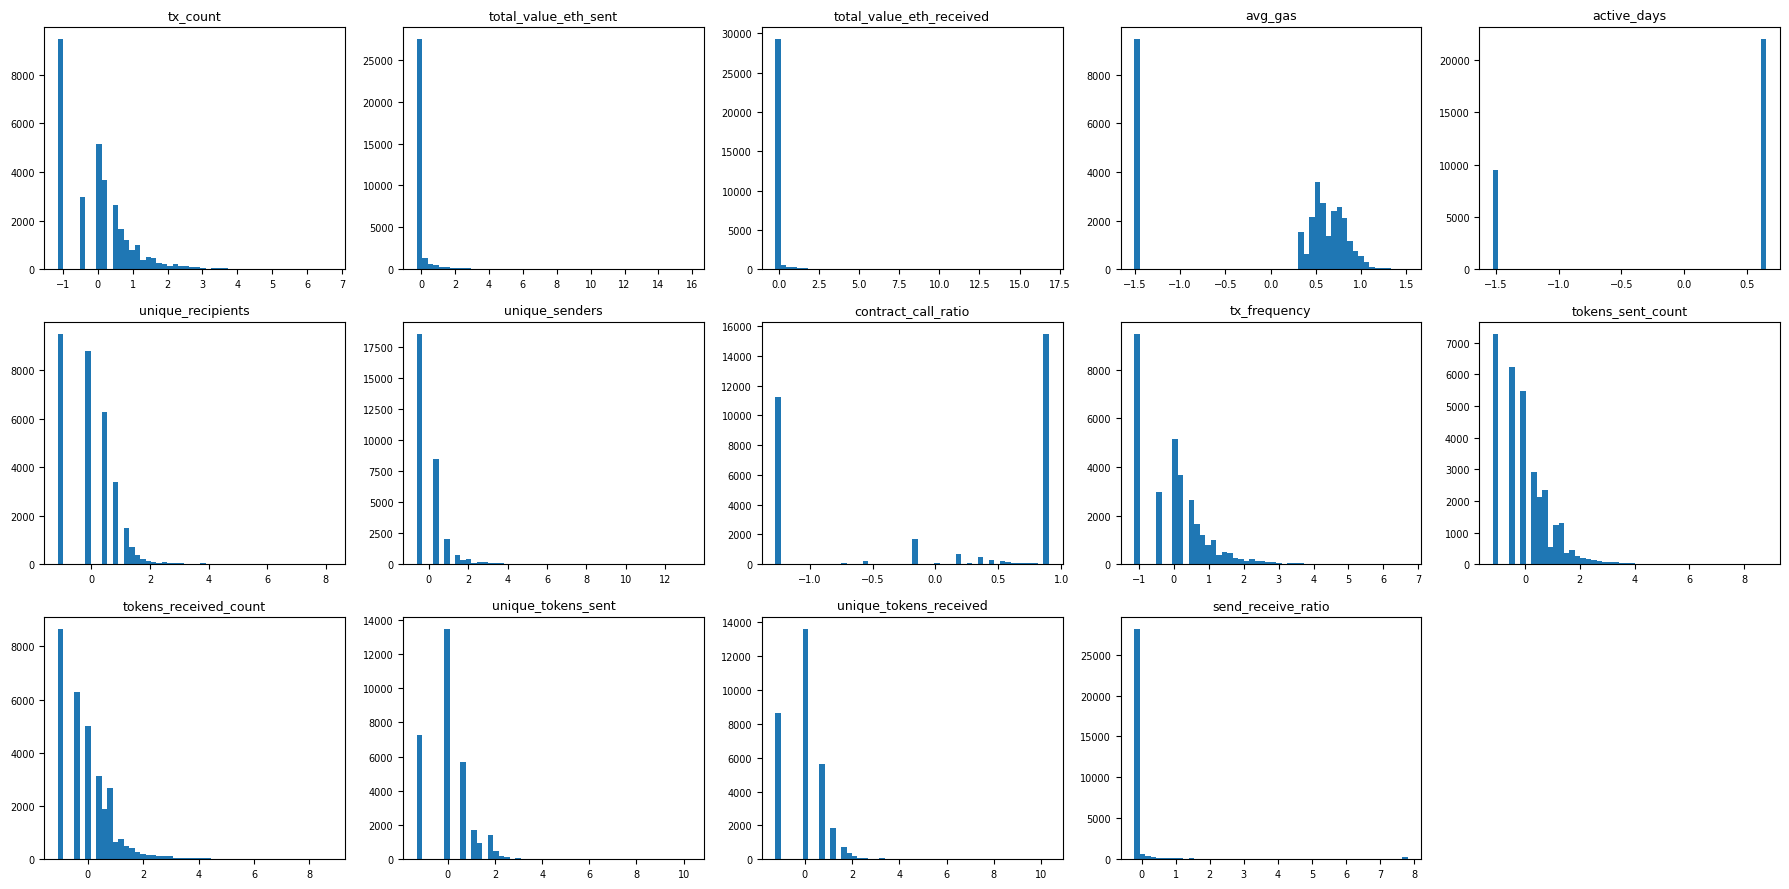

In [16]:
# Cell 10: sanity-check the distributions visually
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(18, 9))
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(X_scaled_df[col], bins=50)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(FEATURE_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../data/processed/feature_distributions.png", dpi=100)
plt.show()